# 02 — SSP Forecast Feature Engineering

Loads all 5 SSP forecast sources, resamples/extrapolates to unified 5-year steps (2025–2100), harmonizes country names to ISO3, and saves `data/processed/ssp_forecast_panel.csv`.

## 0. Setup

In [17]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from forecast_loader import (
    load_excel_gdp_pop,
    load_forecast_corruption,
    load_forecast_employment_agri,
    load_forecast_gini,
    load_forecast_hdi,
    build_forecast_panel,
    add_iso3_codes,
)
from utils import SSP_NAME_TO_ISO3
from config import DATA_RAW_DIR, DATA_PROCESSED_DIR, FORECAST_YEARS_5Y, SSP_SCENARIOS

SCENARIO_COLORS = {"SSP1": "#2ca02c", "SSP4": "#d62728", "SSP5": "#1f77b4"}
DATA_PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
print("Raw dir:       ", DATA_RAW_DIR)
print("Processed dir: ", DATA_PROCESSED_DIR)

Raw dir:        /Users/noahg/Downloads/SSP_v2/src/data/raw
Processed dir:  /Users/noahg/Downloads/SSP_v2/src/data/processed


## 1. Load GDP per capita & Population (Excel)

> **Note:** The 59 MB Excel file takes ~30–60 s to load. Run once and cache if needed.
>
> Units: `gdp_per_capita` in thousand USD_2017/person/yr · `population` in millions

In [18]:
gdp_pop = load_excel_gdp_pop()
print(f"Shape: {gdp_pop.shape}")
gdp_pop.head()

Loading Excel GDP/Pop file (this may take ~30–60 s)…
  GDP/Pop: 200 countries, ['SSP1', 'SSP4', 'SSP5']
Shape: (9600, 5)


,country_name,scenario,year,gdp_per_capita,population
0,Afghanistan,SSP1,2025,NaN,43.793695
1,Afghanistan,SSP1,2030,NaN,49.238560
2,Afghanistan,SSP1,2035,NaN,54.439767
3,Afghanistan,SSP1,2040,NaN,59.275958
4,Afghanistan,SSP1,2045,NaN,63.892211


### 1a. Spot-check GDP per capita trajectories

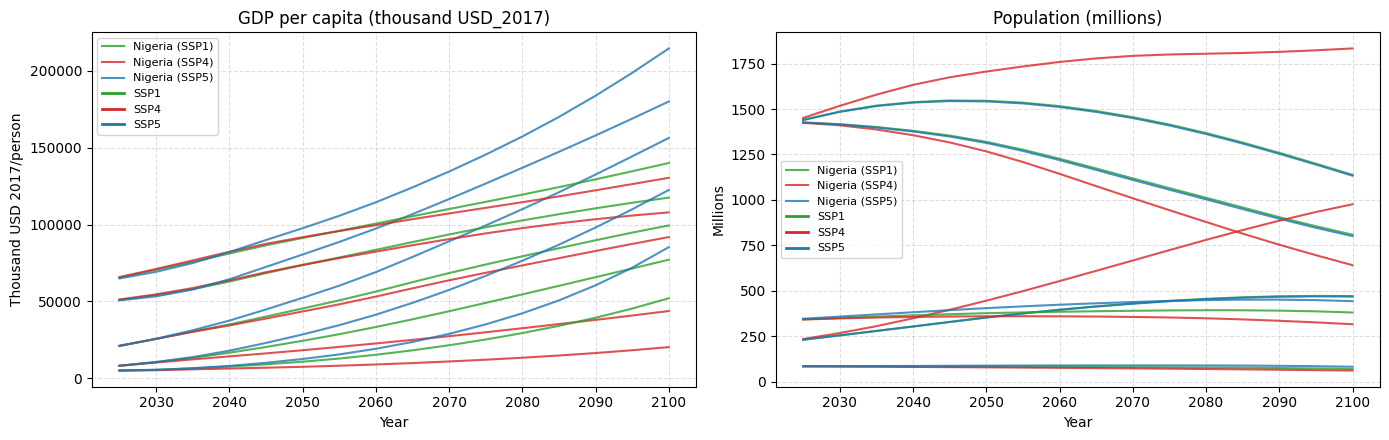

In [19]:
sample = ["Nigeria", "Germany", "India", "China", "United States"]
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

for col, ax, title, ylabel in [
    ("gdp_per_capita", axes[0], "GDP per capita (thousand USD_2017)", "Thousand USD 2017/person"),
    ("population",     axes[1], "Population (millions)",               "Millions"),
]:
    sub = gdp_pop[gdp_pop["country_name"].isin(sample)]
    for (country, ssp), grp in sub.groupby(["country_name", "scenario"]):
        g = grp.sort_values("year")
        ax.plot(g["year"], g[col],
                color=SCENARIO_COLORS.get(ssp, "grey"),
                linewidth=1.5, alpha=0.8,
                label=f"{country} ({ssp})" if country == sample[0] else "_")
    # Add legend entries for scenarios only
    for ssp, c in SCENARIO_COLORS.items():
        ax.plot([], [], color=c, linewidth=2, label=ssp)
    ax.set_title(title); ax.set_xlabel("Year"); ax.set_ylabel(ylabel)
    ax.legend(fontsize=8); ax.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout(); plt.show()

## 2. Load Control of Corruption

Yearly 2015–2099 → resampled to 5-year marks. Year 2100 extrapolated from 2095–2099 linear trend.

In [20]:
corruption, coc_extrap = load_forecast_corruption()
print(f"Shape: {corruption.shape}  |  Extrapolated years: {sorted(coc_extrap)}")
corruption.tail()

Shape: (8304, 4)  |  Extrapolated years: [2100]


,scenario,country_name,year,control_of_corruption
8299,SSP5,Zimbabwe,2080,0.547158
8300,SSP5,Zimbabwe,2085,0.563457
8301,SSP5,Zimbabwe,2090,0.579811
8302,SSP5,Zimbabwe,2095,0.593028
8303,SSP5,Zimbabwe,2100,0.605479


## 3. Load Employment in Agriculture

Mixed steps (yearly 2016–2030, 5-yr 2035–2050). Extrapolated 2055–2100 via linear trend of last 3 points (2040/2045/2050), clipped to [0, 100]%.

Shape: (8352, 4)  |  Extrapolated years: [2055, 2060, 2065, 2070, 2075, 2080, 2085, 2090, 2095, 2100]


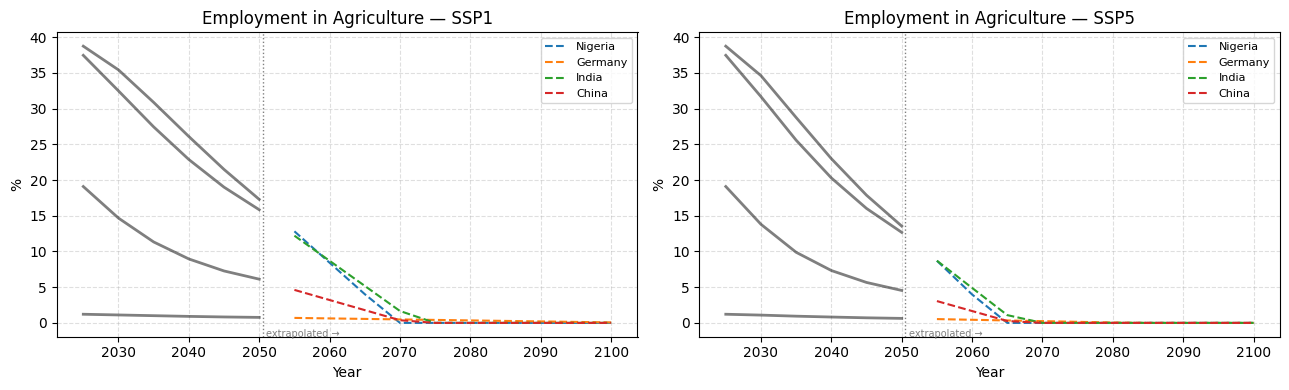

In [21]:
agri, agri_extrap = load_forecast_employment_agri()
print(f"Shape: {agri.shape}  |  Extrapolated years: {sorted(agri_extrap)}")

# Spot-check extrapolation looks sensible
sample_countries = ["Nigeria", "Germany", "India", "China"]
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, ssp in zip(axes, ["SSP1", "SSP5"]):
    for country in sample_countries:
        sub = agri[(agri["country_name"]==country) & (agri["scenario"]==ssp)].sort_values("year")
        known = sub[sub["year"] <= 2050]
        extrap_part = sub[sub["year"] > 2050]
        ax.plot(known["year"],      known["employment_agriculture"],      color="black", alpha=0.5, linewidth=2)
        ax.plot(extrap_part["year"], extrap_part["employment_agriculture"], linestyle="--", linewidth=1.5, label=country)
    ax.axvline(2050.5, color="grey", linestyle=":", linewidth=1)
    ax.text(2051, ax.get_ylim()[0], "extrapolated →", fontsize=7, color="grey")
    ax.set_title(f"Employment in Agriculture — {ssp}"); ax.set_xlabel("Year"); ax.set_ylabel("%")
    ax.legend(fontsize=8); ax.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout(); plt.show()

## 4. Load Gini Coefficient

Already 5-year steps 2015–2100 — no extrapolation needed.

In [22]:
gini, _ = load_forecast_gini()
print(f"Shape: {gini.shape}")
gini.head()

Shape: (8832, 4)


,scenario,country_name,year,gini_coefficient
0,SSP1,Afghanistan,2025,33.139
1,SSP1,Afghanistan,2030,32.813
2,SSP1,Afghanistan,2035,31.837
3,SSP1,Afghanistan,2040,30.440
4,SSP1,Afghanistan,2045,29.079


## 5. Load HDI

5-year steps 2010–2075. Extrapolated 2080–2100 via linear trend of last 3 points (2065/2070/2075), clipped to [0, 1].

Shape: (7392, 4)  |  Extrapolated years: [2080, 2085, 2090, 2095, 2100]


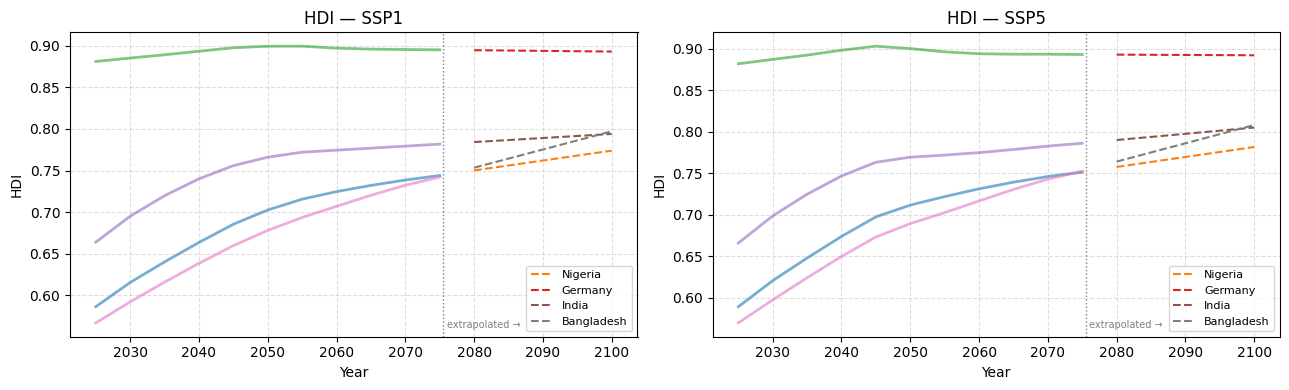

In [23]:
hdi, hdi_extrap = load_forecast_hdi()
print(f"Shape: {hdi.shape}  |  Extrapolated years: {sorted(hdi_extrap)}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, ssp in zip(axes, ["SSP1", "SSP5"]):
    for country in ["Nigeria", "Germany", "India", "Bangladesh"]:
        sub = hdi[(hdi["country_name"]==country) & (hdi["scenario"]==ssp)].sort_values("year")
        known = sub[sub["year"] <= 2075]
        ext   = sub[sub["year"] >  2075]
        ax.plot(known["year"], known["hdi"], linewidth=2, alpha=0.6)
        ax.plot(ext["year"],   ext["hdi"],   linestyle="--", linewidth=1.5, label=country)
    ax.axvline(2075.5, color="grey", linestyle=":", linewidth=1)
    ax.text(2076, ax.get_ylim()[0]+0.01, "extrapolated →", fontsize=7, color="grey")
    ax.set_title(f"HDI — {ssp}"); ax.set_xlabel("Year"); ax.set_ylabel("HDI")
    ax.legend(fontsize=8); ax.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout(); plt.show()

## 6. Country name harmonization — coverage check

All SSP sources use IIASA naming. We map to ISO3 via `SSP_NAME_TO_ISO3`. Check for any unmapped countries before merging.

In [24]:
# Test ISO3 mapping on all country names across all sources
all_names = set()
for df in [gdp_pop, corruption, agri, gini, hdi]:
    all_names.update(df["country_name"].unique())

unmapped = sorted([n for n in all_names if n not in SSP_NAME_TO_ISO3])
print(f"Total unique country names across all sources: {len(all_names)}")
print(f"Mapped to ISO3:  {len(all_names) - len(unmapped)}")
print(f"Unmapped:        {len(unmapped)}")
if unmapped:
    print("Unmapped names:", unmapped)
else:
    print("All country names successfully mapped to ISO3.")

Total unique country names across all sources: 200
Mapped to ISO3:  192
Unmapped:        8
Unmapped names: ['Cabo Verde', 'Curaçao', 'Guadeloupe', 'Hong Kong', 'Martinique', 'Puerto Rico', 'Réunion', 'Singapore']


## 7. Source coverage comparison

Not every country appears in every source. Document the overlap before merging.

In [25]:
source_sets = {
    "gdp_pop":    set(gdp_pop["country_name"].unique()),
    "corruption": set(corruption["country_name"].unique()),
    "agri":       set(agri["country_name"].unique()),
    "gini":       set(gini["country_name"].unique()),
    "hdi":        set(hdi["country_name"].unique()),
}

print(f"{'Source':<15}  {'n countries':>12}")
for name, s in source_sets.items():
    print(f"  {name:<13}  {len(s):>12}")

all_sources = set.intersection(*source_sets.values())
any_source  = set.union(*source_sets.values())
print(f"\n  In ALL sources:    {len(all_sources)}")
print(f"  In ANY source:     {len(any_source)}")
print(f"  Missing from ≥1:   {len(any_source) - len(all_sources)}")

# Countries missing from multiple sources
rows = []
for country in sorted(any_source):
    rows.append({"country": country,
                 **{src: country in s for src, s in source_sets.items()}})
coverage_df = pd.DataFrame(rows)
missing_from_any = coverage_df[~coverage_df[list(source_sets.keys())].all(axis=1)]
print(f"\nCountries missing from at least one source ({len(missing_from_any)}):")
print(missing_from_any.to_string(index=False))

Source            n countries
  gdp_pop                 200
  corruption              173
  agri                    174
  gini                    184
  hdi                     154

  In ALL sources:    150
  In ANY source:     200
  Missing from ≥1:   50

Countries missing from at least one source (50):
                     country  gdp_pop  corruption  agri  gini   hdi
                 Afghanistan     True       False  True  True False
                     Albania     True       False  True  True False
                      Angola     True       False  True  True False
         Antigua and Barbuda     True       False False False False
                       Aruba     True       False False  True False
                    Barbados     True        True  True  True False
                    Botswana     True        True  True  True False
           Brunei Darussalam     True        True  True  True False
                        Cuba     True        True False  True  True
               

## 8. Build unified forecast panel

Outer-join all sources on `country_name × scenario × year`. Countries present in only some sources will have NaN for missing variables.

In [26]:
# This runs the full pipeline (loads all files, merges, saves)
panel = build_forecast_panel()
print(f"\nPanel shape: {panel.shape}")
panel.head(10)

Loading Excel GDP/Pop file (this may take ~30–60 s)…
  GDP/Pop: 200 countries, ['SSP1', 'SSP4', 'SSP5']

Saved: /Users/noahg/Downloads/SSP_v2/src/data/processed/ssp_forecast_panel.csv
  Shape:            (9600, 13)
  Countries:        200
  Scenarios:        ['SSP1', 'SSP4', 'SSP5']
  Year range:       2025–2100
  Agri extrapolated: years [2055, 2060, 2065, 2070, 2075, 2080, 2085, 2090, 2095, 2100]
  HDI  extrapolated: years [2080, 2085, 2090, 2095, 2100]
  CoC  extrapolated: years [2100]

Panel shape: (9600, 13)


/Users/noahg/Downloads/SSP_v2/src/forecast_loader.py:410: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .transform(lambda s: s.ffill().bfill())


,country_name,country_code,scenario,year,gdp_per_capita,population,hdi,control_of_corruption,employment_agriculture,gini_coefficient,employment_agriculture_extrap,hdi_extrap,coc_extrap
0,Afghanistan,AFG,SSP1,2025,NaN,43.793695,NaN,NaN,47.48,33.139,False,False,False
1,Afghanistan,AFG,SSP1,2030,NaN,49.238560,NaN,NaN,45.09,32.813,False,False,False
2,Afghanistan,AFG,SSP1,2035,NaN,54.439767,NaN,NaN,41.00,31.837,False,False,False
3,Afghanistan,AFG,SSP1,2040,NaN,59.275958,NaN,NaN,36.16,30.440,False,False,False
4,Afghanistan,AFG,SSP1,2045,NaN,63.892211,NaN,NaN,30.96,29.079,False,False,False
5,Afghanistan,AFG,SSP1,2050,NaN,68.115675,NaN,NaN,25.82,27.875,False,False,False
6,Afghanistan,AFG,SSP1,2055,NaN,71.776000,NaN,NaN,20.64,26.806,True,False,False
7,Afghanistan,AFG,SSP1,2060,NaN,74.779051,NaN,NaN,15.47,25.912,True,False,False
8,Afghanistan,AFG,SSP1,2065,NaN,77.207245,NaN,NaN,10.30,25.196,True,False,False
9,Afghanistan,AFG,SSP1,2070,NaN,79.017442,NaN,NaN,5.13,24.622,True,False,False


## 9. Data quality check — missingness in forecast panel

In [27]:
value_cols = ["gdp_per_capita", "population", "hdi",
              "control_of_corruption", "employment_agriculture", "gini_coefficient"]

print(f"{'Variable':<28}  {'% missing':>10}  {'n missing':>10}")
total = len(panel)
for col in value_cols:
    n_miss = panel[col].isna().sum()
    print(f"  {col:<26}  {n_miss/total*100:>9.1f}%  {n_miss:>10,}")

print(f"\nTotal rows: {total:,}  |  Countries: {panel['country_name'].nunique()}  |  "
      f"Scenarios: {panel['scenario'].unique().tolist()}  |  "
      f"Years: {panel['year'].min()}–{panel['year'].max()}")

Variable                       % missing   n missing
  gdp_per_capita                    4.0%         384
  population                        0.0%           0
  hdi                              23.0%       2,208
  control_of_corruption            13.5%       1,296
  employment_agriculture           13.0%       1,248
  gini_coefficient                  8.0%         768

Total rows: 9,600  |  Countries: 200  |  Scenarios: ['SSP1', 'SSP4', 'SSP5']  |  Years: 2025–2100


## 10. Extrapolation flag summary

In [28]:
flag_cols = ["employment_agriculture_extrap", "hdi_extrap", "coc_extrap"]
print("Extrapolated rows per flag:")
for col in flag_cols:
    n = panel[col].sum()
    pct = n / len(panel) * 100
    extrap_yrs = sorted(panel[panel[col]]["year"].unique())
    print(f"  {col:<36}  {n:>6,} rows ({pct:.1f}%)  years: {extrap_yrs}")

Extrapolated rows per flag:
  employment_agriculture_extrap          6,000 rows (62.5%)  years: [np.int64(2055), np.int64(2060), np.int64(2065), np.int64(2070), np.int64(2075), np.int64(2080), np.int64(2085), np.int64(2090), np.int64(2095), np.int64(2100)]
  hdi_extrap                             3,000 rows (31.2%)  years: [np.int64(2080), np.int64(2085), np.int64(2090), np.int64(2095), np.int64(2100)]
  coc_extrap                               600 rows (6.2%)  years: [np.int64(2100)]


## 11. Scenario divergence visualisation

Spot-check that SSP1/SSP4/SSP5 show expected divergence for key variables.

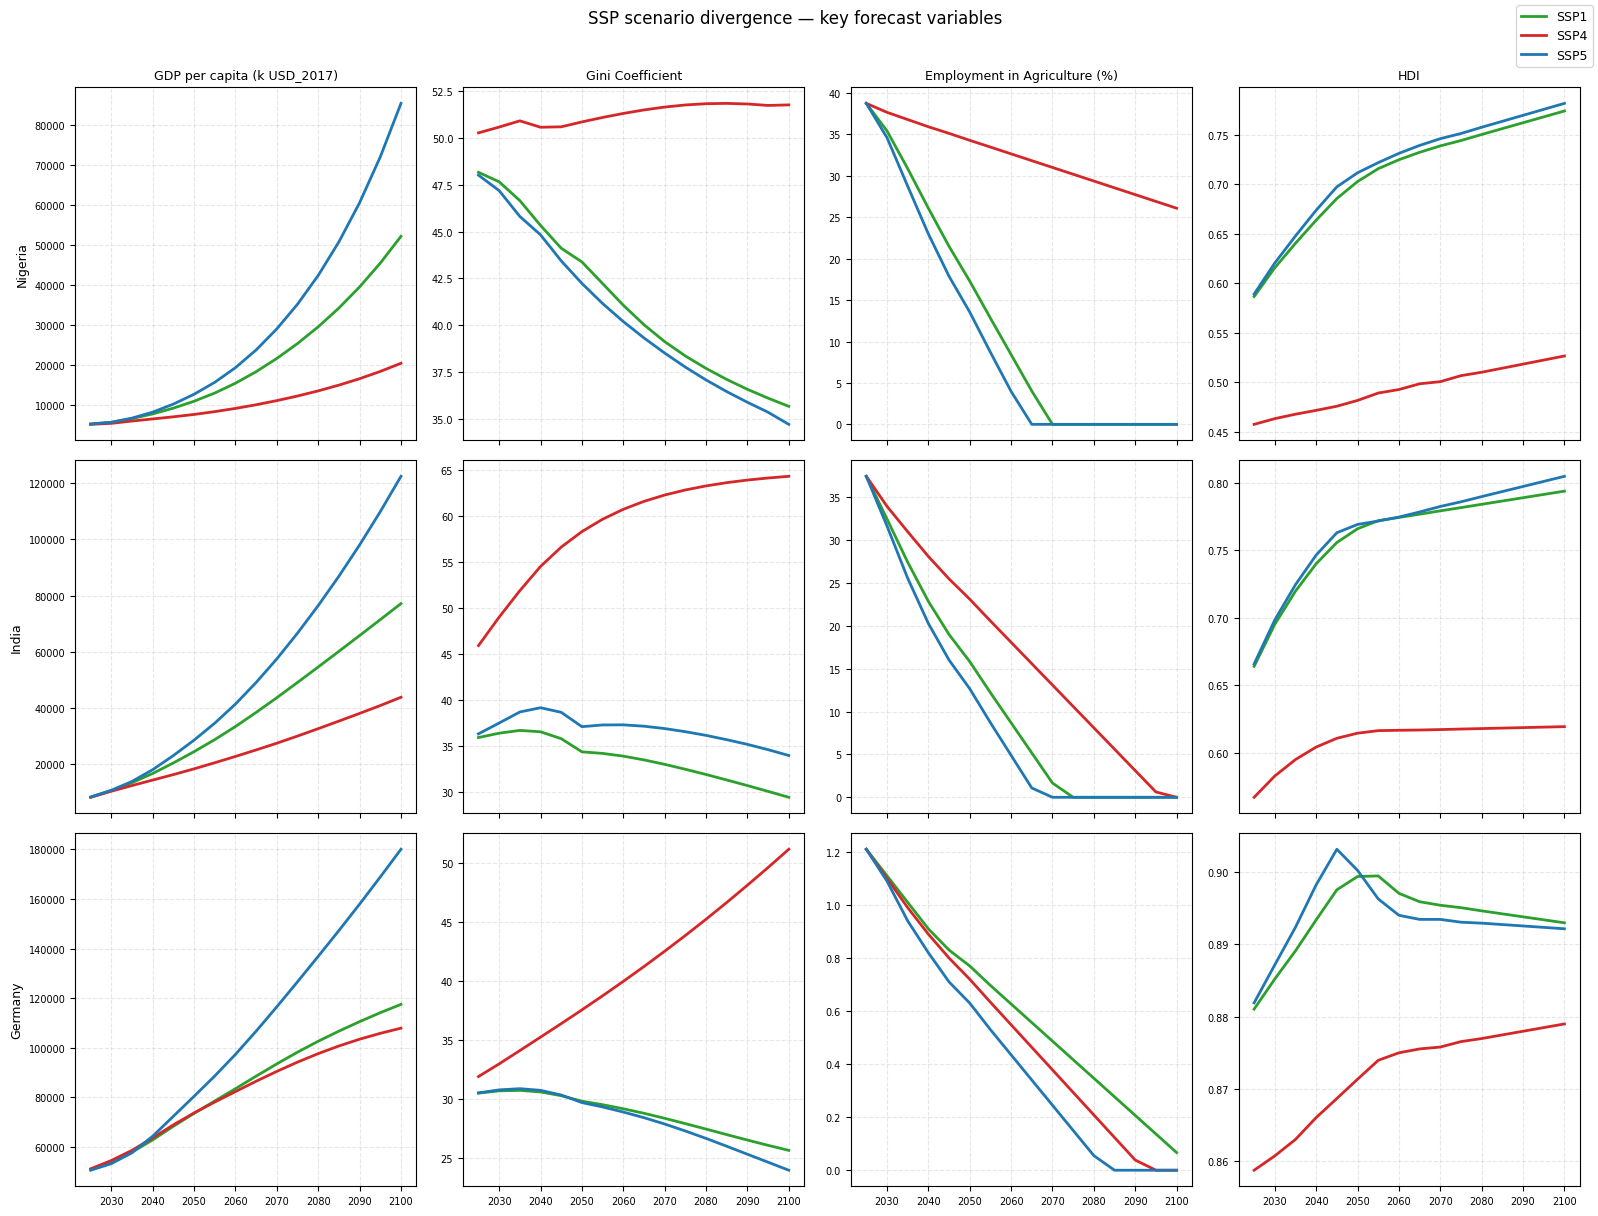

In [29]:
sample_countries = ["Nigeria", "India", "Germany"]
vars_to_plot = [
    ("gdp_per_capita",        "GDP per capita (k USD_2017)"),
    ("gini_coefficient",      "Gini Coefficient"),
    ("employment_agriculture","Employment in Agriculture (%)"),
    ("hdi",                   "HDI"),
]

fig, axes = plt.subplots(len(sample_countries), len(vars_to_plot),
                         figsize=(16, 4 * len(sample_countries)), sharex=True)

for r, country in enumerate(sample_countries):
    sub = panel[panel["country_name"] == country]
    for c, (col, title) in enumerate(vars_to_plot):
        ax = axes[r][c]
        for ssp in SSP_SCENARIOS:
            s = sub[sub["scenario"] == ssp].sort_values("year")
            ax.plot(s["year"], s[col], color=SCENARIO_COLORS[ssp],
                    linewidth=2, label=ssp if r == 0 and c == 0 else "_")
        if r == 0: ax.set_title(title, fontsize=9)
        if c == 0: ax.set_ylabel(country, fontsize=9)
        ax.grid(True, linestyle="--", alpha=0.3)
        ax.tick_params(labelsize=7)

handles = [plt.Line2D([0],[0],color=c,linewidth=2,label=s) for s,c in SCENARIO_COLORS.items()]
fig.legend(handles=handles, loc="upper right", fontsize=9)
plt.suptitle("SSP scenario divergence — key forecast variables", y=1.01)
plt.tight_layout()
plt.show()

## 12. Save summary

In [30]:
out = DATA_PROCESSED_DIR / "ssp_forecast_panel.csv"
print(f"Output file: {out}")
print(f"  Rows:      {len(panel):,}")
print(f"  Columns:   {panel.columns.tolist()}")
print(f"\nCountries with complete data across all 6 variables:")
complete = panel.dropna(subset=value_cols)
print(f"  {complete['country_name'].nunique()} countries fully complete")

Output file: /Users/noahg/Downloads/SSP_v2/src/data/processed/ssp_forecast_panel.csv
  Rows:      9,600
  Columns:   ['country_name', 'country_code', 'scenario', 'year', 'gdp_per_capita', 'population', 'hdi', 'control_of_corruption', 'employment_agriculture', 'gini_coefficient', 'employment_agriculture_extrap', 'hdi_extrap', 'coc_extrap']

Countries with complete data across all 6 variables:
  150 countries fully complete


---

# Part II — ML-Ready Training Dataset

Transforms `data/processed/historical_panel.csv` into scaled feature matrices and saves all training artefacts to `data/final/`.

**Pipeline summary**
1. Extract historical population from IIASA Excel → compute `gdp_per_capita`
2. Derive `log_gdp_pc`, `log_population`, `gdp_growth_5y`
3. One-hot encode WB region (SSA = baseline)
4. Temporal split: **train 1996–2015 / test 2016–2022**
5. Fit `StandardScaler` on train only → transform both splits
6. Build 5-fold stratified CV (stratified by country income quartile)
7. Save `X_train.csv`, `X_test.csv`, `y_train.csv`, `y_test.csv`, `feature_scaler.pkl`, `feature_names.json`


## 13. Setup — Part II imports

In [31]:
from feature_engineering import (
    load_historical_population_from_excel,
    add_gdp_per_capita,
    add_log_transforms,
    add_gdp_growth_5y,
    add_region_onehot,
    temporal_split,
    build_Xy,
    get_cv_folds,
    save_training_files,
    build_training_dataset,
    FINAL_FEATURE_COLS,
    POVERTY_TARGET_COLS,
    TRAIN_END_YEAR,
    TEST_START_YEAR,
    MIN_TRAIN_YEAR,
    N_CV_FOLDS,
)
from config import DATA_PROCESSED_DIR, DATA_FINAL_DIR
import seaborn as sns
from sklearn.preprocessing import StandardScaler

DATA_FINAL_DIR.mkdir(parents=True, exist_ok=True)
print("Feature columns:", FINAL_FEATURE_COLS)
print("Target columns: ", POVERTY_TARGET_COLS)

Feature columns: ['log_gdp_pc', 'log_population', 'hdi', 'control_of_corruption', 'employment_agriculture', 'gini_coefficient', 'gdp_growth_5y', 'region_EAP', 'region_ECA', 'region_LAC', 'region_MENA', 'region_NAC', 'region_SAS']
Target columns:  ['poverty_3', 'poverty_4_20', 'poverty_8_30', 'poverty_10']


## 14. Load historical panel

Load the cleaned, imputed panel produced by `preprocessing.py` and `01_data_cleaning.ipynb`.

In [32]:
panel_path = DATA_PROCESSED_DIR / "historical_panel.csv"
panel_raw  = pd.read_csv(panel_path)

print(f"Shape:     {panel_raw.shape}")
print(f"Countries: {panel_raw['country_name'].nunique()}")
print(f"Years:     {panel_raw['year'].min()} – {panel_raw['year'].max()}")
print(f"\nColumns:")
for c in panel_raw.columns:
    n_null = panel_raw[c].isna().sum()
    print(f"  {c:<35} {n_null:>5} NaN  ({n_null/len(panel_raw)*100:.1f}%)")
panel_raw.head()

Shape:     (8044, 13)
Countries: 273
Years:     1993 – 2023

Columns:
  country_name                            0 NaN  (0.0%)
  country_code                         1317 NaN  (16.4%)
  year                                    0 NaN  (0.0%)
  gdp                                  1317 NaN  (16.4%)
  hdi                                  2185 NaN  (27.2%)
  control_of_corruption                1317 NaN  (16.4%)
  employment_agriculture               1317 NaN  (16.4%)
  gini_coefficient                     1317 NaN  (16.4%)
  poverty_3                            1317 NaN  (16.4%)
  poverty_4_20                         1317 NaN  (16.4%)
  poverty_8_30                         5612 NaN  (69.8%)
  poverty_10                           5612 NaN  (69.8%)
  high_imputation_flag                    0 NaN  (0.0%)


,country_name,country_code,year,gdp,hdi,control_of_corruption,employment_agriculture,gini_coefficient,poverty_3,poverty_4_20,poverty_8_30,poverty_10,high_imputation_flag
0,Afghanistan,AFG,1993,3.521418e+09,0.312,-1.291705,67.886100,35.200000,3.521418e+09,3.521418e+09,NaN,NaN,True
1,Afghanistan,AFG,1994,3.521418e+09,0.307,-1.291705,67.907431,35.200000,3.521418e+09,3.521418e+09,NaN,NaN,True
2,Afghanistan,AFG,1995,3.521418e+09,0.331,-1.291705,67.451958,35.200000,3.521418e+09,3.521418e+09,NaN,NaN,True
3,Afghanistan,AFG,1996,3.521418e+09,0.335,-1.291705,67.170502,36.085714,3.521418e+09,3.521418e+09,NaN,NaN,True
4,Afghanistan,AFG,1997,3.521418e+09,0.339,-1.233859,66.859165,36.771429,3.521418e+09,3.521418e+09,NaN,NaN,True


## 15. Historical population from IIASA Excel

Extracts the "Historical Reference / Population" sheet from the 59 MB Excel file and interpolates from 5-year marks to yearly 1993–2022.

> **First run** takes ~60 s; result is cached to `data/processed/historical_population_iiasa.csv`.

In [33]:
excel_path = DATA_RAW_DIR / "GDP(Forecast)_POP_SSP_1950_2100.xlsx"
pop_df = load_historical_population_from_excel(excel_path)

print(f"Shape: {pop_df.shape}")
print(f"Countries: {pop_df['country_name'].nunique()}")
print(f"Year range: {pop_df['year'].min()} – {pop_df['year'].max()}")
print(f"Unmapped ISO3: {pop_df['country_code'].isna().sum()} rows")
pop_df.head(10)

Loading cached population: /Users/noahg/Downloads/SSP_v2/src/data/processed/historical_population_iiasa.csv
Shape: (6000, 4)
Countries: 200
Year range: 1993 – 2022
Unmapped ISO3: 240 rows


,country_name,year,population_M,country_code
0,Afghanistan,1993,13.981443,AFG
1,Afghanistan,1994,15.026616,AFG
2,Afghanistan,1995,16.071789,AFG
3,Afghanistan,1996,16.791414,AFG
4,Afghanistan,1997,17.511039,AFG
5,Afghanistan,1998,18.230663,AFG
6,Afghanistan,1999,18.950288,AFG
7,Afghanistan,2000,19.669913,AFG
8,Afghanistan,2001,20.507159,AFG
9,Afghanistan,2002,21.344404,AFG


## 16. Add GDP per capita & log transforms

`gdp_per_capita = GDP_USD / (population_M × 1e6)`  
`log_gdp_pc = log(gdp_per_capita)` — poverty is approximately log-linear in income  
`log_population = log(population_M × 1e6)`

In [34]:
panel = add_gdp_per_capita(panel_raw.copy(), pop_df)
panel = add_log_transforms(panel)

# Coverage check
n_total = len(panel)
n_gdp_pc_ok = panel["gdp_per_capita"].notna().sum()
print(f"gdp_per_capita computed for {n_gdp_pc_ok:,} / {n_total:,} rows "
      f"({n_gdp_pc_ok/n_total*100:.1f}%)")

# Spot-check a few countries
sample = ["Nigeria", "Germany", "India", "China", "United States"]
sub = panel[panel["country_name"].isin(sample) & (panel["year"] == 2010)]
print("\nGDP per capita spot-check (2010, USD/person):")
print(sub[["country_name", "gdp_per_capita", "log_gdp_pc"]].to_string(index=False))

gdp_per_capita computed for 5,010 / 8,044 rows (62.3%)

GDP per capita spot-check (2010, USD/person):
 country_name  gdp_per_capita  log_gdp_pc
        China     4608.600161    8.435679
      Germany    42654.372816   10.660885
        India     1359.983274    7.215228
      Nigeria     2311.995272    7.745866
United States    48563.208607   10.790621


## 17. 5-year GDP growth rate

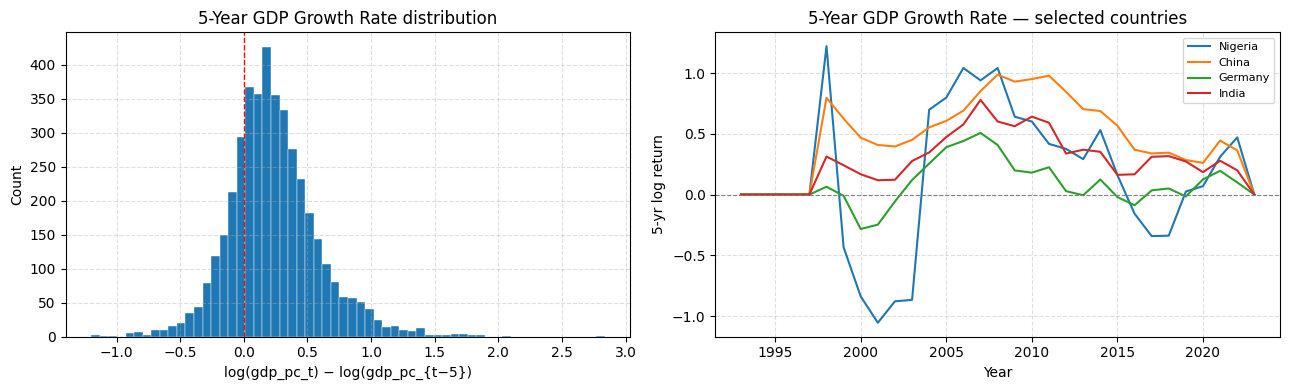


gdp_growth_5y stats:
count    8044.000
mean        0.122
std         0.281
min        -1.199
25%         0.000
50%         0.000
75%         0.215
max         2.837
Name: gdp_growth_5y, dtype: float64


In [35]:
panel = add_gdp_growth_5y(panel)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Distribution of gdp_growth_5y
ax = axes[0]
vals = panel["gdp_growth_5y"].dropna()
vals = vals[vals != 0]  # exclude NaN-filled zeros for display
ax.hist(vals, bins=60, color="#1f77b4", edgecolor="white", linewidth=0.3)
ax.axvline(0, color="red", linestyle="--", linewidth=1)
ax.set_title("5-Year GDP Growth Rate distribution")
ax.set_xlabel("log(gdp_pc_t) − log(gdp_pc_{t−5})")
ax.set_ylabel("Count")
ax.grid(True, linestyle="--", alpha=0.4)

# Trajectory for sample countries
ax = axes[1]
for country in ["Nigeria", "China", "Germany", "India"]:
    sub = panel[panel["country_name"] == country].sort_values("year")
    ax.plot(sub["year"], sub["gdp_growth_5y"], linewidth=1.5, label=country)
ax.axhline(0, color="grey", linestyle="--", linewidth=0.8)
ax.set_title("5-Year GDP Growth Rate — selected countries")
ax.set_xlabel("Year"); ax.set_ylabel("5-yr log return")
ax.legend(fontsize=8); ax.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout(); plt.show()
print(f"\ngdp_growth_5y stats:\n{panel['gdp_growth_5y'].describe().round(3)}")

## 18. Region one-hot encoding

Map each country to its World Bank region, then one-hot encode. **SSA (Sub-Saharan Africa) is the baseline** — dropped from the feature matrix so that SSA countries have all region dummies = 0.

In [36]:
panel = add_region_onehot(panel)

region_cols = [c for c in panel.columns if c.startswith("region_")]
print("Region dummy columns:", region_cols)

# Count countries per region
region_coverage = (
    panel.drop_duplicates("country_name")
    .assign(_region=lambda d: d[region_cols].idxmax(axis=1)
            .where(d[region_cols].any(axis=1), "region_SSA"))
    ["_region"].str.replace("region_", "")
    .value_counts()
)
print("\nCountries per region:")
print(region_coverage.to_string())

# Countries that map to SSA baseline (all zeros)
ssa_countries = sorted(
    panel[panel[region_cols].sum(axis=1) == 0]["country_name"].unique()
)
print(f"\nSSA baseline countries ({len(ssa_countries)}): {ssa_countries[:10]} ...")

Region dummy columns: ['region_EAP', 'region_ECA', 'region_LAC', 'region_MENA', 'region_NAC', 'region_SAS']

Countries per region:
_region
SSA     125
ECA      53
LAC      33
EAP      31
MENA     20
SAS       8
NAC       3

SSA baseline countries (125): ['American Samoa', 'Angola', 'Argentina (urban)', 'Aruba', 'Bahamas', 'Benin', 'Bolivia (Plurinational State of)', 'Botswana', 'British Virgin Islands', 'Burkina Faso'] ...


## 19. Temporal split

| Split | Years | Purpose |
|-------|-------|---------|
| Train | 1996–2015 | Model fitting & CV |
| Test  | 2016–2022 | Hold-out evaluation |

> Early years (<1996) excluded: governance (Control of Corruption) and HDI data are sparse before 1996.

Training set: years 1996–2015
  Rows:       5,194
  Countries:  273

Test set: years 2016–2023
  Rows:       2,080
  Countries:  265


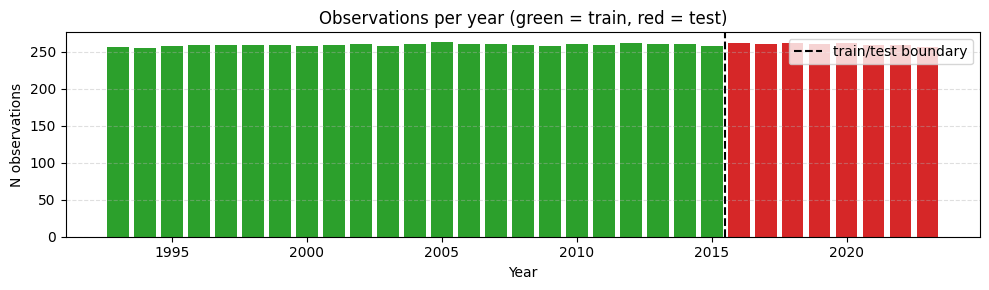

In [37]:
train_df, test_df = temporal_split(panel)

print(f"Training set: years {MIN_TRAIN_YEAR}–{TRAIN_END_YEAR}")
print(f"  Rows:       {len(train_df):,}")
print(f"  Countries:  {train_df['country_name'].nunique()}")
print(f"\nTest set: years {TEST_START_YEAR}–{panel['year'].max()}")
print(f"  Rows:       {len(test_df):,}")
print(f"  Countries:  {test_df['country_name'].nunique()}")

# Visualise train / test year boundary
fig, ax = plt.subplots(figsize=(10, 3))
years = panel["year"].value_counts().sort_index()
colors = ["#2ca02c" if y <= TRAIN_END_YEAR else "#d62728" for y in years.index]
ax.bar(years.index, years.values, color=colors, width=0.8)
ax.axvline(TRAIN_END_YEAR + 0.5, color="black", linestyle="--", linewidth=1.5, label="train/test boundary")
ax.set_title("Observations per year (green = train, red = test)")
ax.set_xlabel("Year"); ax.set_ylabel("N observations"); ax.legend()
ax.grid(True, linestyle="--", alpha=0.4, axis="y")
plt.tight_layout(); plt.show()

## 20. Build X / y matrices

Rows where ANY feature is NaN are dropped (they cannot be used to train/evaluate the model).

In [38]:
X_train_raw, y_train = build_Xy(train_df)
X_test_raw,  y_test  = build_Xy(test_df)

print(f"X_train: {X_train_raw.shape}  |  y_train: {y_train.shape}")
print(f"X_test:  {X_test_raw.shape}   |  y_test:  {y_test.shape}")

# NaN in poverty targets
print("\nNaN counts in poverty targets (train):")
for col in POVERTY_TARGET_COLS:
    n = y_train[col].isna().sum()
    print(f"  {col:<20}: {n:>4} NaN ({n/len(y_train)*100:.1f}%)")

X_train: (3180, 13)  |  y_train: (3180, 4)
X_test:  (1113, 13)   |  y_test:  (1113, 4)

NaN counts in poverty targets (train):
  poverty_3           :    0 NaN (0.0%)
  poverty_4_20        :    0 NaN (0.0%)
  poverty_8_30        : 2084 NaN (65.5%)
  poverty_10          : 2084 NaN (65.5%)


## 21. Feature distributions (training set)

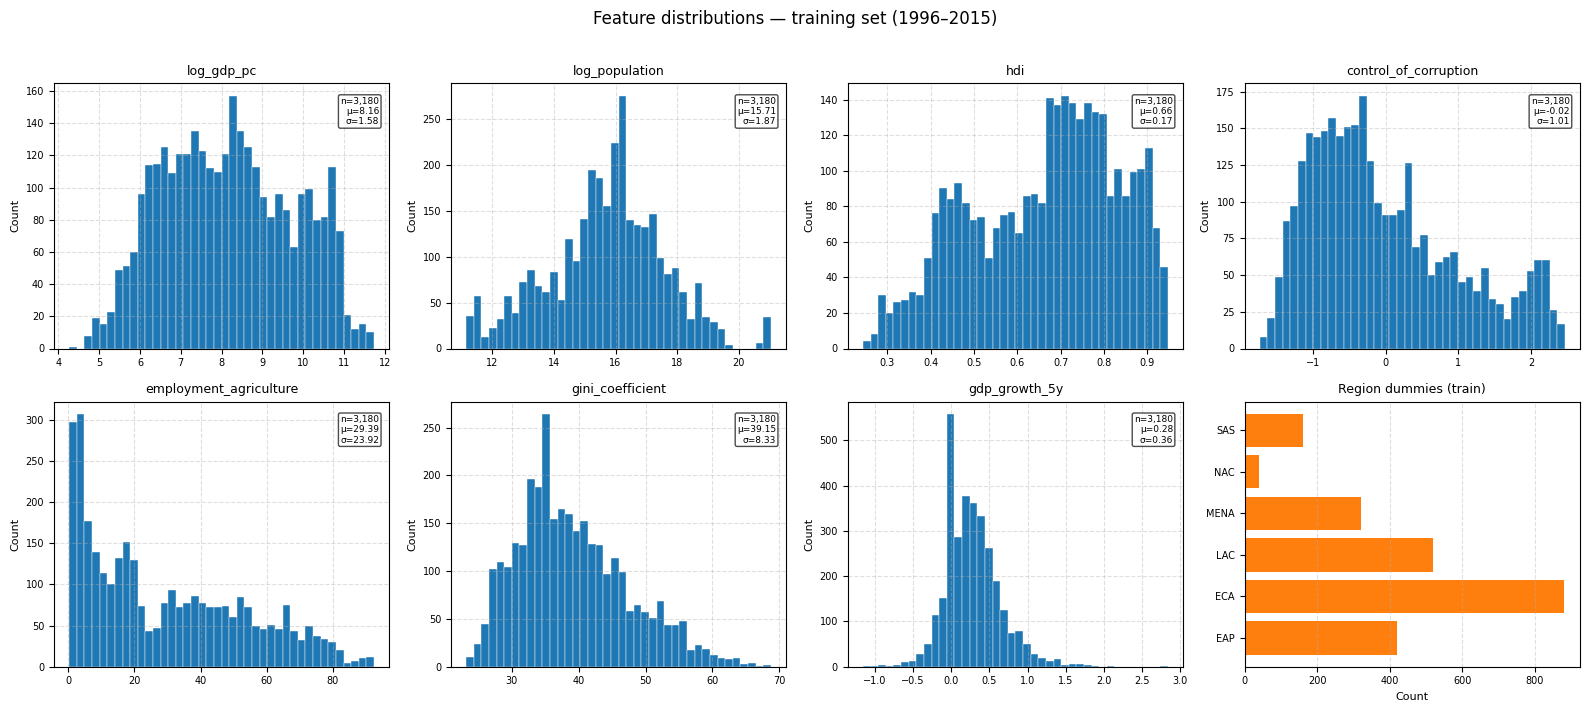

In [39]:
continuous_features = [
    "log_gdp_pc", "log_population", "hdi", "control_of_corruption",
    "employment_agriculture", "gini_coefficient", "gdp_growth_5y",
]

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()

for i, feat in enumerate(continuous_features):
    ax = axes[i]
    vals = X_train_raw[feat].dropna()
    ax.hist(vals, bins=40, color="#1f77b4", edgecolor="white", linewidth=0.3)
    ax.set_title(feat, fontsize=9)
    ax.set_ylabel("Count", fontsize=8)
    ax.tick_params(labelsize=7)
    ax.grid(True, linestyle="--", alpha=0.4)
    ax.text(0.97, 0.95, f"n={len(vals):,}\nμ={vals.mean():.2f}\nσ={vals.std():.2f}",
            transform=ax.transAxes, fontsize=6.5,
            va="top", ha="right", color="black",
            bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.7))

# Region dummy bar chart in the last panel
ax = axes[7]
region_counts = X_train_raw[[c for c in X_train_raw.columns if c.startswith("region_")]].sum()
ax.barh(region_counts.index.str.replace("region_", ""), region_counts.values, color="#ff7f0e")
ax.set_title("Region dummies (train)", fontsize=9)
ax.set_xlabel("Count", fontsize=8)
ax.tick_params(labelsize=7)
ax.grid(True, linestyle="--", alpha=0.4, axis="x")

plt.suptitle("Feature distributions — training set (1996–2015)", y=1.01)
plt.tight_layout(); plt.show()

## 22. Feature correlation heatmap

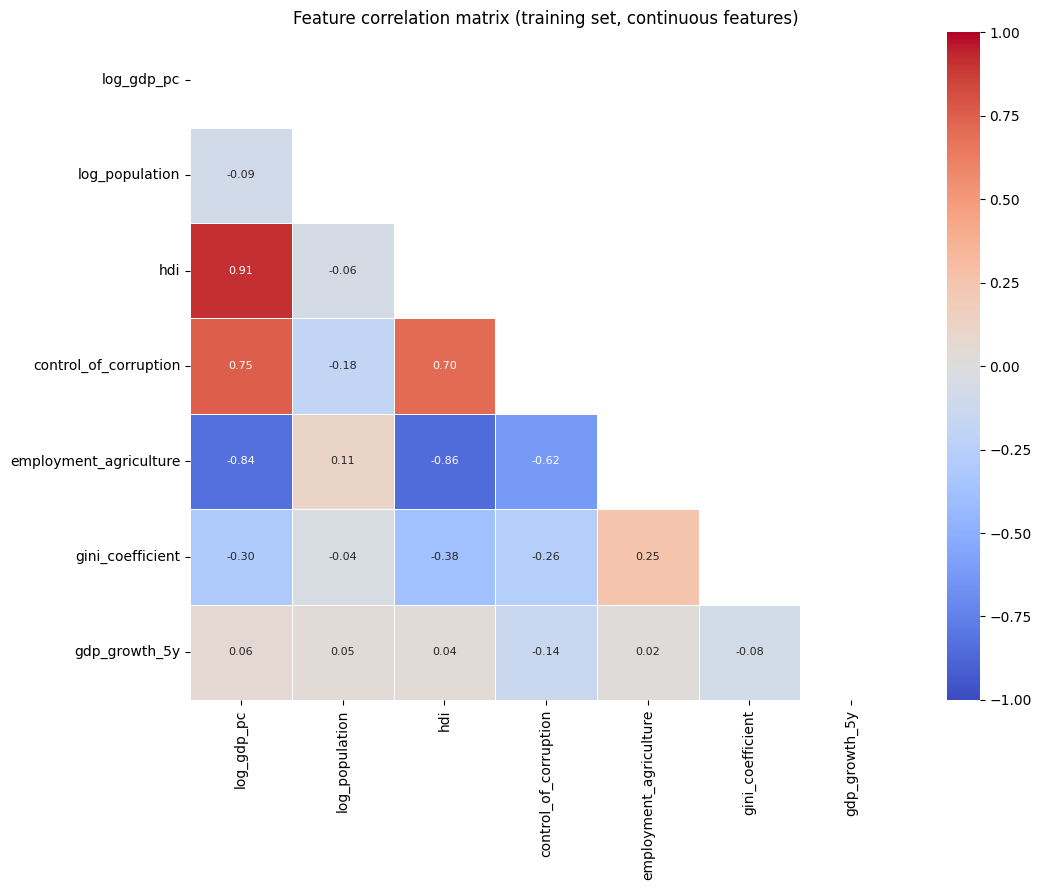

In [40]:
fig, ax = plt.subplots(figsize=(11, 9))
corr = X_train_raw[continuous_features].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, vmin=-1, vmax=1, linewidths=0.5,
            annot_kws={"size": 8}, ax=ax)
ax.set_title("Feature correlation matrix (training set, continuous features)")
plt.tight_layout(); plt.show()

## 23. Feature vs target scatter (log_gdp_pc vs poverty)

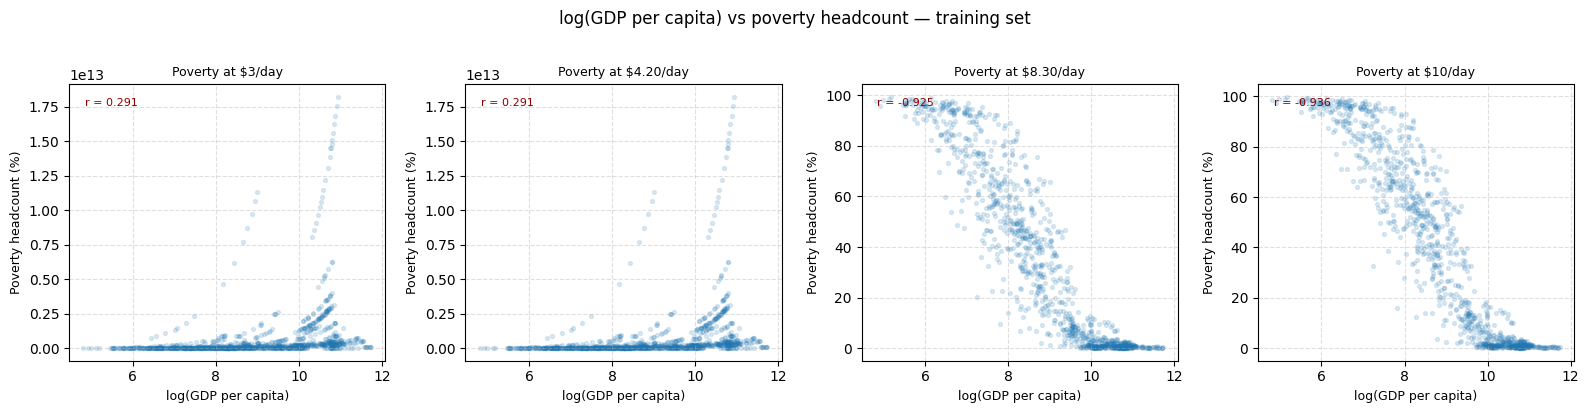

In [41]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=False)
targets_labels = {
    "poverty_3":    "$3/day",
    "poverty_4_20": "$4.20/day",
    "poverty_8_30": "$8.30/day",
    "poverty_10":   "$10/day",
}

# Align X and y by index
plot_df = pd.concat([X_train_raw[["log_gdp_pc"]], y_train], axis=1).dropna()

for ax, (tgt, label) in zip(axes, targets_labels.items()):
    ax.scatter(plot_df["log_gdp_pc"], plot_df[tgt],
               alpha=0.15, s=8, color="#1f77b4")
    ax.set_xlabel("log(GDP per capita)", fontsize=9)
    ax.set_ylabel("Poverty headcount (%)", fontsize=9)
    ax.set_title(f"Poverty at {label}", fontsize=9)
    ax.grid(True, linestyle="--", alpha=0.4)
    # Add correlation annotation
    r = plot_df[["log_gdp_pc", tgt]].dropna().corr().iloc[0, 1]
    ax.text(0.05, 0.95, f"r = {r:.3f}", transform=ax.transAxes,
            fontsize=8, va="top", color="darkred")

plt.suptitle("log(GDP per capita) vs poverty headcount — training set", y=1.02)
plt.tight_layout(); plt.show()

## 24. Scale features

`StandardScaler` fitted on the **training set only** to prevent data leakage.  
Verify that scaled training features have μ ≈ 0, σ ≈ 1.

In [42]:
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train_raw),
    columns=X_train_raw.columns,
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test_raw),
    columns=X_test_raw.columns,
)

print("Train scaled feature stats (should be μ≈0, σ≈1):")
stats = X_train_scaled.describe().T[["mean","std","min","max"]].round(3)
print(stats.to_string())

print(f"\nTest set scaled (using train scaler — values may differ from 0/1):")
stats_test = X_test_scaled[["log_gdp_pc","hdi","gini_coefficient"]].describe().T[["mean","std"]].round(3)
print(stats_test.to_string())

Train scaled feature stats (should be μ≈0, σ≈1):
                        mean  std    min    max
log_gdp_pc              -0.0  1.0 -2.466  2.259
log_population          -0.0  1.0 -2.441  2.851
hdi                      0.0  1.0 -2.501  1.692
control_of_corruption    0.0  1.0 -1.693  2.468
employment_agriculture  -0.0  1.0 -1.218  2.638
gini_coefficient         0.0  1.0 -1.921  3.557
gdp_growth_5y            0.0  1.0 -3.957  7.069
region_EAP              -0.0  1.0 -0.390  2.563
region_ECA               0.0  1.0 -0.619  1.617
region_LAC               0.0  1.0 -0.442  2.262
region_MENA             -0.0  1.0 -0.334  2.990
region_NAC               0.0  1.0 -0.113  8.860
region_SAS              -0.0  1.0 -0.230  4.345

Test set scaled (using train scaler — values may differ from 0/1):
                   mean    std
log_gdp_pc        0.363  0.893
hdi               0.365  0.910
gini_coefficient -0.281  0.851


## 25. Cross-validation fold composition

5-fold `StratifiedKFold` stratified by country median `poverty_3` quartile.  
Each fold should contain a balanced mix of high, middle, and low poverty countries.

5-fold CV composition:
Fold     Train rows   Val rows   Val pct
  1         2,544        636     20.0%
  2         2,544        636     20.0%
  3         2,544        636     20.0%
  4         2,544        636     20.0%
  5         2,544        636     20.0%


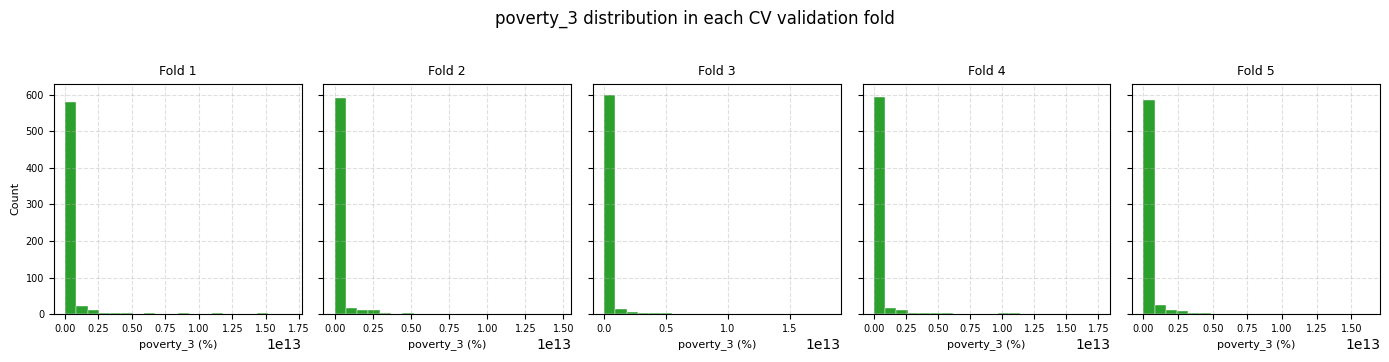

In [43]:
cv_folds = get_cv_folds(train_df, X_train_raw)

print(f"{N_CV_FOLDS}-fold CV composition:")
print(f"{'Fold':<6}  {'Train rows':>11}  {'Val rows':>9}  {'Val pct':>8}")
for i, (tr_idx, va_idx) in enumerate(cv_folds):
    n_tr, n_va = len(tr_idx), len(va_idx)
    print(f"  {i+1}    {n_tr:>10,}  {n_va:>9,}  {n_va/(n_tr+n_va)*100:>7.1f}%")

# Show poverty distribution per fold
fig, axes = plt.subplots(1, N_CV_FOLDS, figsize=(14, 3.5), sharey=True)
for i, (_, va_idx) in enumerate(cv_folds):
    pov = y_train.iloc[va_idx]["poverty_3"].dropna()
    axes[i].hist(pov, bins=20, color="#2ca02c", edgecolor="white", linewidth=0.3)
    axes[i].set_title(f"Fold {i+1}", fontsize=9)
    axes[i].set_xlabel("poverty_3 (%)", fontsize=8)
    axes[i].tick_params(labelsize=7)
    axes[i].grid(True, linestyle="--", alpha=0.4)

axes[0].set_ylabel("Count", fontsize=8)
plt.suptitle("poverty_3 distribution in each CV validation fold", y=1.02)
plt.tight_layout(); plt.show()

## 26. Run full pipeline & save artefacts

`build_training_dataset()` runs all steps above end-to-end and saves outputs to `data/final/`.

In [44]:
result = build_training_dataset(
    panel_path = DATA_PROCESSED_DIR / "historical_panel.csv",
    excel_path = DATA_RAW_DIR       / "GDP(Forecast)_POP_SSP_1950_2100.xlsx",
    output_dir = DATA_FINAL_DIR,
)

Loading historical panel…
  Panel shape: (8044, 13)
Loading cached population: /Users/noahg/Downloads/SSP_v2/src/data/processed/historical_population_iiasa.csv

Split:
  Train: years 1996–2015  (273 countries, 5,194 rows)
  Test:  years 2016–2023  (265 countries, 2,080 rows)

  X_train: (3180, 13)  |  y_train: (3180, 4)
  X_test:  (1113, 13)   |  y_test:  (1113, 4)
    poverty_3           :    0 NaN targets in train (0.0%)
    poverty_4_20        :    0 NaN targets in train (0.0%)
    poverty_8_30        : 2084 NaN targets in train (65.5%)
    poverty_10          : 2084 NaN targets in train (65.5%)

  5-fold CV: [636, 636, 636, 636, 636] val rows per fold

Saved training artefacts to: /Users/noahg/Downloads/SSP_v2/src/data/final
  X_test.csv                            288,169 bytes
  X_train.csv                           822,138 bytes
  cv_folds.json                          90,025 bytes
  feature_names.json                        240 bytes
  feature_scaler.pkl                      1,0

## 27. Verify saved output files

In [45]:
import json as _json, pickle as _pickle

print("=== Files in data/final/ ===")
for p in sorted(DATA_FINAL_DIR.iterdir()):
    print(f"  {p.name:<35}  {p.stat().st_size:>10,} bytes")

# Spot-check loaded files round-trip correctly
X_train_check = pd.read_csv(DATA_FINAL_DIR / "X_train.csv")
X_test_check  = pd.read_csv(DATA_FINAL_DIR / "X_test.csv")
y_train_check = pd.read_csv(DATA_FINAL_DIR / "y_train.csv")
y_test_check  = pd.read_csv(DATA_FINAL_DIR / "y_test.csv")

print(f"\nRound-trip shapes:")
print(f"  X_train: {X_train_check.shape}  |  y_train: {y_train_check.shape}")
print(f"  X_test:  {X_test_check.shape}   |  y_test:  {y_test_check.shape}")

with open(DATA_FINAL_DIR / "feature_names.json") as f:
    feat_names = _json.load(f)
print(f"\nFeature names ({len(feat_names)}): {feat_names}")

with open(DATA_FINAL_DIR / "split_metadata.json") as f:
    meta = _json.load(f)
print(f"\nSplit metadata:")
for k, v in meta.items():
    print(f"  {k}: {v}")

=== Files in data/final/ ===
  X_test.csv                              288,169 bytes
  X_train.csv                             822,138 bytes
  cv_folds.json                            90,025 bytes
  feature_names.json                          240 bytes
  feature_scaler.pkl                        1,014 bytes
  poverty_predictions_ssp.csv           1,367,854 bytes
  split_metadata.json                         848 bytes
  y_test.csv                               47,691 bytes
  y_train.csv                             131,824 bytes

Round-trip shapes:
  X_train: (3180, 13)  |  y_train: (3180, 4)
  X_test:  (1113, 13)   |  y_test:  (1113, 4)

Feature names (13): ['log_gdp_pc', 'log_population', 'hdi', 'control_of_corruption', 'employment_agriculture', 'gini_coefficient', 'gdp_growth_5y', 'region_EAP', 'region_ECA', 'region_LAC', 'region_MENA', 'region_NAC', 'region_SAS']

Split metadata:
  train_year_range: [1996, 2015]
  test_year_range: [2016, 2023]
  n_train_rows: 3180
  n_test_rows: 1113

## 28. Summary

| Artefact | Path | Description |
|----------|------|-------------|
| `X_train.csv` | `data/final/` | Scaled feature matrix, 1996–2015 |
| `X_test.csv`  | `data/final/` | Scaled feature matrix, 2016–2022 |
| `y_train.csv` | `data/final/` | 4 poverty targets, train period |
| `y_test.csv`  | `data/final/` | 4 poverty targets, test period |
| `feature_scaler.pkl` | `data/final/` | Fitted `StandardScaler` |
| `feature_names.json` | `data/final/` | Ordered list of 13 feature names |
| `split_metadata.json` | `data/final/` | Train/test sizes, year ranges |
| `cv_folds.json` | `data/final/` | 5-fold CV index arrays |

**Next:** `03_model_training.ipynb` — train 7 ML models × 4 poverty thresholds using `X_train.csv` / `y_train.csv`.